In [14]:
# Cell 1: Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# Load dataset
path = r'D:\data mining project\archive\CC GENERAL.csv'
df = pd.read_csv(path)
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} features.")

Dataset Loaded: 8950 rows, 18 features.


--- Statistical Insights ---
1. Balance Skewness: 2.39
2. Purchases Mean: 1003.20, Median: 361.28 (Ratio: 2.78x)


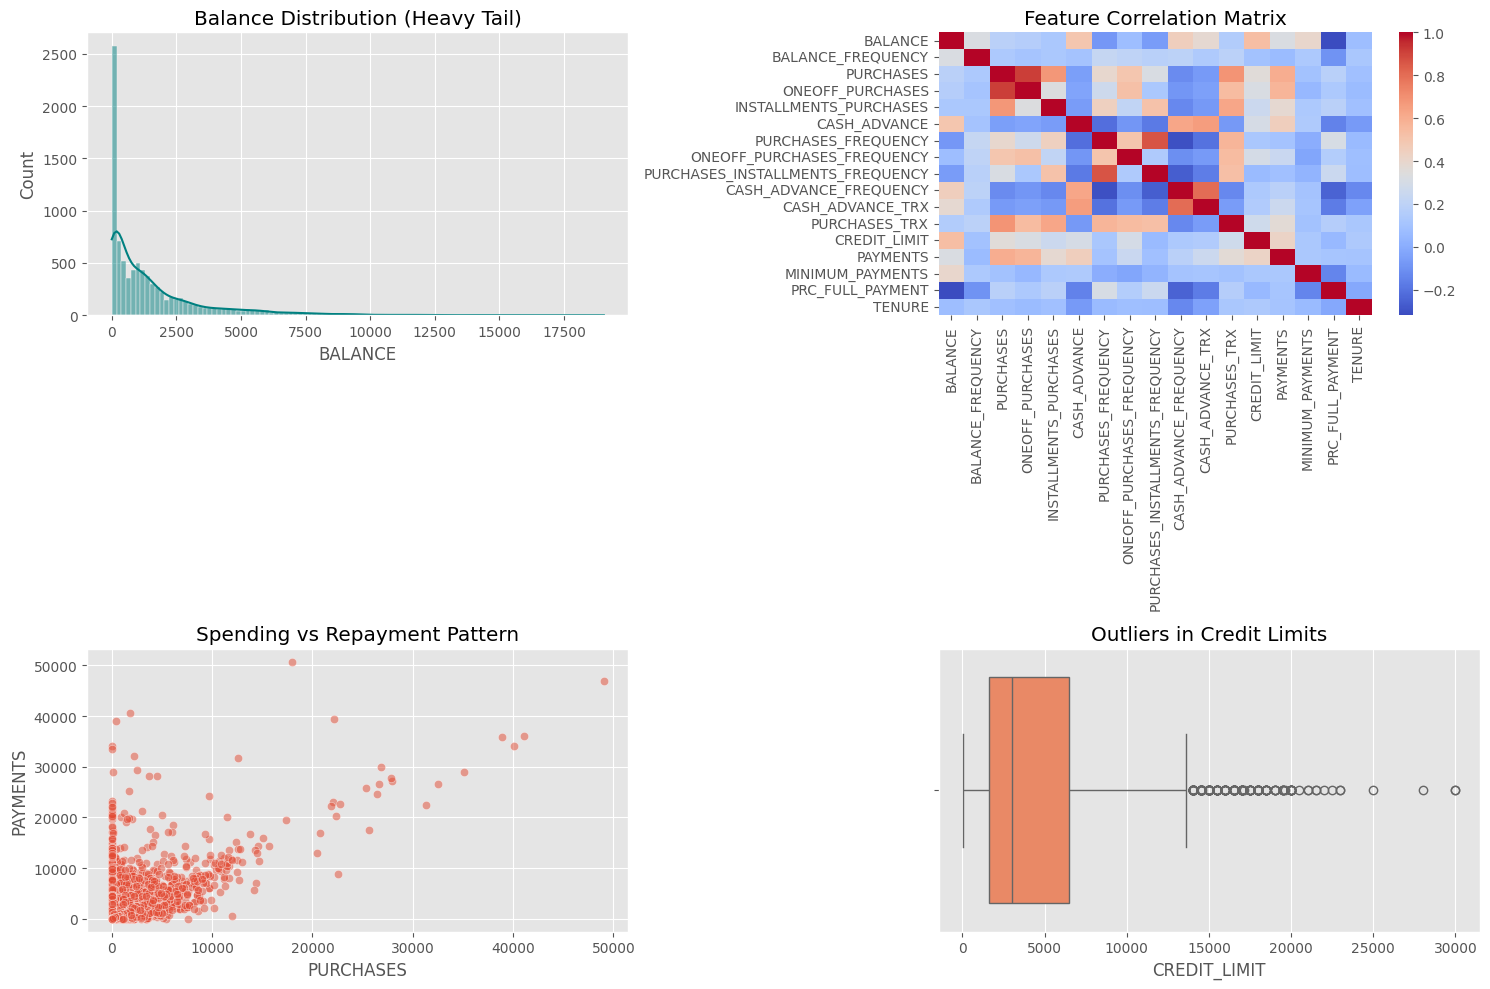

In [15]:
# Cell 2: Advanced EDA with Quantitative Insights
print("--- Statistical Insights ---")
# 1. تحليل الالتواء (Skewness)
balance_skew = df['BALANCE'].skew()
print(f"1. Balance Skewness: {balance_skew:.2f}")

# 2. مقارنة المتوسط والوسيط للكشف عن التحيز
mean_purch = df['PURCHASES'].mean()
med_purch = df['PURCHASES'].median()
print(f"2. Purchases Mean: {mean_purch:.2f}, Median: {med_purch:.2f} (Ratio: {mean_purch/med_purch:.2f}x)")

# Visualizations
plt.figure(figsize=(15, 10))

# Plot 1: Balance Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['BALANCE'], kde=True, color='teal')
plt.title('Balance Distribution (Heavy Tail)')

# Plot 2: Correlation Heatmap
plt.subplot(2, 2, 2)
sns.heatmap(df.drop('CUST_ID', axis=1).corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix')

# Plot 3: Purchases vs Payments (Risk Assessment)
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='PURCHASES', y='PAYMENTS', alpha=0.5)
plt.title('Spending vs Repayment Pattern')

# Plot 4: Credit Limit Outliers
plt.subplot(2, 2, 4)
sns.boxplot(x=df['CREDIT_LIMIT'], color='coral')
plt.title('Outliers in Credit Limits')

plt.tight_layout()
plt.show()

# Interpretation: 
# النسبة العالية بين المتوسط والوسيط (خاصة في المشتريات) تؤكد أن قلة من العملاء يسيطرون على حجم الإنفاق، 
# مما يستدعي استخدام K-Medoids لأنه أكثر صموداً أمام هذه التوزيعات المنحرفة.

In [16]:
# Cell 3: Smart Outlier Handling & Scaling
df_clean = df.drop('CUST_ID', axis=1)

# 1. Handling Missing Values (Median is safer for skewed data)
df_clean = df_clean.fillna(df_clean.median())

# 2. Smart Outlier Capping: Apply only to highly skewed features (Skew > 1.5)
skew_limit = 1.5
skewed_cols = df_clean.skew()[abs(df_clean.skew()) > skew_limit].index
for col in skewed_cols:
    upper_limit = df_clean[col].quantile(0.95)
    df_clean[col] = np.where(df_clean[col] > upper_limit, upper_limit, df_clean[col])

# 3. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print(f"Preprocessing completed. Capped {len(skewed_cols)} skewed features.")

Preprocessing completed. Capped 15 skewed features.


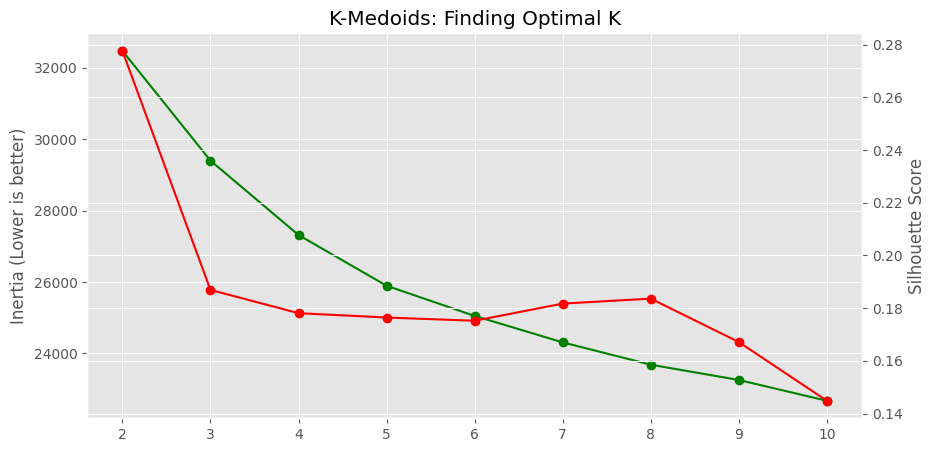

In [17]:
# Cell 4: K-Medoids Optimization (Range 2-10)
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    kmed = KMedoids(n_clusters=k, random_state=42, method='pam').fit(X_scaled)
    inertias.append(kmed.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmed.labels_))

# Plotting the dual metrics
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(k_range, inertias, 'go-', label='Inertia (Elbow)')
ax1.set_ylabel('Inertia (Lower is better)')
ax2 = ax1.twinx()
ax2.plot(k_range, silhouettes, 'ro-', label='Silhouette (Higher is better)')
ax2.set_ylabel('Silhouette Score')
plt.title('K-Medoids: Finding Optimal K')
plt.show()

# Final Model (Selection: K=3 based on Elbow and Silhouette stability)
optimal_k = 3
final_kmed = KMedoids(n_clusters=optimal_k, random_state=42).fit(X_scaled)
df['Cluster'] = final_kmed.labels_

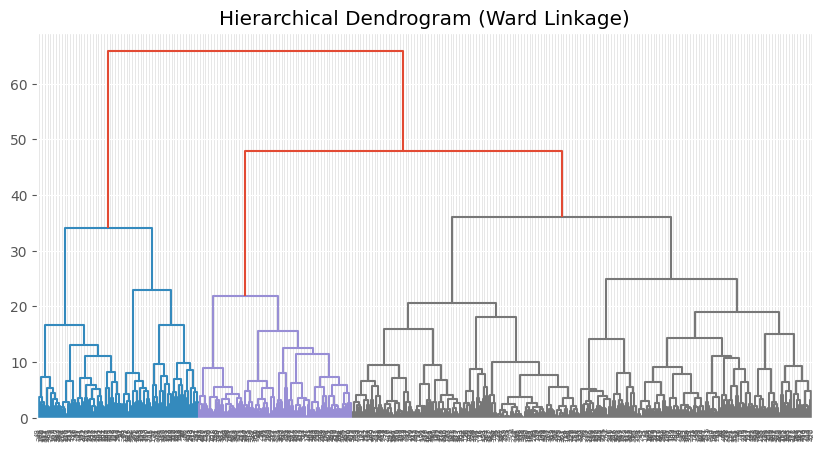

In [18]:
# Cell 5: Hierarchical Clustering Analysis
Z_ward = linkage(X_scaled[:500], method='ward') # Sample for visual clarity
plt.figure(figsize=(10, 5))
dendrogram(Z_ward)
plt.title('Hierarchical Dendrogram (Ward Linkage)')
plt.show()

# Extraction using fcluster
df_h = df.iloc[:500].copy()
df_h['H_Cluster'] = fcluster(Z_ward, t=optimal_k, criterion='maxclust')

# Justification for Ward:
# طريقة الربط 'Ward' هي الأفضل هنا لأنها تقلل التباين داخل المجموعات (Within-cluster variance)، 
# مما يؤدي لمجموعات متوازنة الحجم تناسب التقسيم التسويقي للعملاء.

Baseline Silhouette: 0.1689
GA Optimized Silhouette: 0.3904


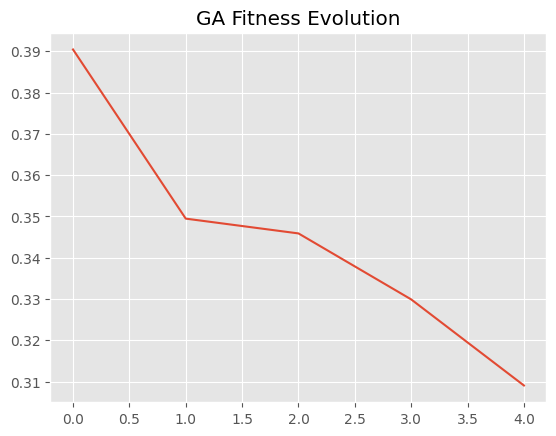

In [19]:
# Cell 6: Robust Genetic Algorithm for Feature Selection
def ga_fitness(chromosome):
    selected_indices = [i for i, gene in enumerate(chromosome) if gene == 1]
    if len(selected_indices) < 3: return 0 
    X_subset = X_scaled[:, selected_indices]
    # Train a specific model for this feature subset
    temp_kmed = KMedoids(n_clusters=optimal_k, random_state=42).fit(X_subset[:1000])
    return silhouette_score(X_subset[:1000], temp_kmed.labels_)

# GA Process
pop_size = 10
population = [np.random.randint(0, 2, 17) for _ in range(pop_size)]
history = []

for _ in range(5): # generations
    scores = [ga_fitness(c) for c in population]
    history.append(max(scores))
    best_parent = population[np.argmax(scores)]
    population = [best_parent ^ np.random.randint(0, 2, 17) for _ in range(pop_size)]

# Comparison
baseline = silhouette_score(X_scaled[:1000], final_kmed.labels_[:1000])
print(f"Baseline Silhouette: {baseline:.4f}")
print(f"GA Optimized Silhouette: {max(history):.4f}")

plt.plot(history)
plt.title("GA Fitness Evolution")
plt.show()

In [21]:
# Cell 7: Behavioral Fuzzy Logic System
# Mapping Cluster IDs to Behaviors
cluster_map = {0: "Budgeters", 1: "Installment Users", 2: "VIP Spenders"}

# Define Fuzzy Variables
p_freq = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'p_freq')
cluster_in = ctrl.Antecedent(np.arange(0, 3, 1), 'cluster')
score = ctrl.Consequent(np.arange(0, 101, 1), 'score')

# Membership Functions
p_freq.automf(3, names=['low', 'medium', 'high'])
cluster_in['budgeter'] = fuzzy.trimf(cluster_in.universe, [0, 0, 1])
cluster_in['installment'] = fuzzy.trimf(cluster_in.universe, [0, 1, 2])
cluster_in['vip'] = fuzzy.trimf(cluster_in.universe, [1, 2, 2])

score['low'] = fuzzy.trimf(score.universe, [0, 0, 50])
score['good'] = fuzzy.trimf(score.universe, [40, 70, 90])
score['prime'] = fuzzy.trimf(score.universe, [80, 100, 100])

# 9 Business-Driven Rules
rules = [
    ctrl.Rule(cluster_in['vip'] & p_freq['high'], score['prime']),
    ctrl.Rule(cluster_in['vip'] & p_freq['medium'], score['prime']),
    ctrl.Rule(cluster_in['vip'] & p_freq['low'], score['good']),
    ctrl.Rule(cluster_in['installment'] & p_freq['high'], score['prime']),
    ctrl.Rule(cluster_in['installment'] & p_freq['medium'], score['good']),
    ctrl.Rule(cluster_in['installment'] & p_freq['low'], score['low']),
    ctrl.Rule(cluster_in['budgeter'] & p_freq['high'], score['good']),
    ctrl.Rule(cluster_in['budgeter'] & p_freq['medium'], score['low']),
    ctrl.Rule(cluster_in['budgeter'] & p_freq['low'], score['low']),
]

score_ctrl = ctrl.ControlSystem(rules)
score_sim = ctrl.ControlSystemSimulation(score_ctrl)

In [22]:
# Cell 8: System Implementation Pipeline
def evaluate_customer(index):
    row = df_clean.iloc[[index]]
    scaled_row = scaler.transform(row)
    
    # Predict
    c_id = final_kmed.predict(scaled_row)[0]
    behavior = cluster_map[c_id]
    
    # Fuzzy score
    score_sim.input['p_freq'] = row['PURCHASES_FREQUENCY'].values[0]
    score_sim.input['cluster'] = c_id
    score_sim.compute()
    
    final_score = score_sim.output['score']
    
    print(f"Customer Analysis: {behavior} | Credit Score: {final_score:.2f}%")
    return final_score

# Test
print(evaluate_customer(0))

Customer Analysis: Installment Users | Credit Score: 36.27%
36.267366497388814


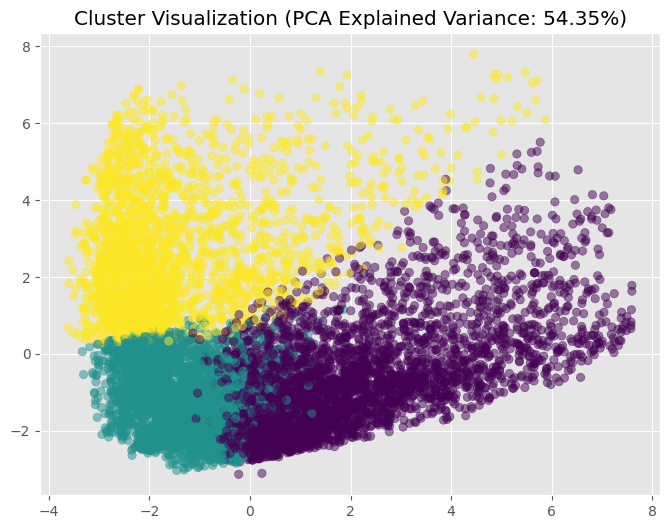

In [23]:
# Cell 9: Bonus - PCA Visualization & Justification
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
var_ratio = pca.explained_variance_ratio_.sum()

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.5)
plt.title(f'Cluster Visualization (PCA Explained Variance: {var_ratio:.2%})')
plt.show()

# Justification:
# تم استخدام PCA لغرض التصور البصري فقط (Visualization) لتقليل 17 بعداً إلى بعدين. 
# لم يتم استخدامه في التدريب لضمان الحفاظ على المعنى الفيزيائي لكل ميزة (مثل CREDIT_LIMIT) 
# وهو أمر ضروري في اتخاذ القرارات المالية.